### Initial Steps

In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [135]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [136]:
# Load Excel file
source_file = pd.ExcelFile('OrganDonor_Consolidated.xlsx')

# Initialize an empty dictionary to store DataFrames
dfs = {}

# Iterate over each sheet name
for sheet_name in source_file.sheet_names:
    # Load the sheet into a DataFrame
    df = source_file.parse(sheet_name)
    # Modify the sheet name to create a key for the dictionary
    key = sheet_name + '_df'
    # Store the DataFrame in the dictionary with the modified name as the key
    dfs[key] = df

In [137]:
# Access the required DataFrames directly
DonorDetails_df = dfs['DonorDetails_df']
ReferralDetails_df = dfs['ReferralDetails_df']
Outcomes_df = dfs['Outcomes_df']
OPO_HospDetails_df = dfs['OPO_HospDetails_df']
Yearly_Outcomes_df = dfs['Yearly_Outcomes_df']

In [138]:

# Print the shapes of all DataFrames
for df_name, df in dfs.items():
    print(f"{df_name}: {df.shape}")
    print(f"{df_name}: {df.info()}")

DonorDetails_df: (133101, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133101 entries, 0 to 133100
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   PatientID           133101 non-null  object        
 1   age                 133017 non-null  float64       
 2   gender              133040 non-null  object        
 3   race                133101 non-null  object        
 4   causeofdeath        133101 non-null  object        
 5   mechanism_of_death  133101 non-null  object        
 6   brain_death         133101 non-null  int64         
 7   time_asystole       89446 non-null   datetime64[ns]
 8   time_brain_death    11856 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(5)
memory usage: 9.1+ MB
DonorDetails_df: None
ReferralDetails_df: (133101, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133101 entries, 0 to 133100
Data columns (total 

 ### 1: Using numpy functions, multiply the following arrays using matrix multiplication.  a=np.arange(4).reshape(2,2)  b=np.arange(6).reshape(3,2)  DONE

In [139]:
a=np.arange(4).reshape(2,2)
b=np.arange(6).reshape(3,2)

# matrix a
print("Matrix a: ")
print(a)

# matrix b , used \n for adding a blank line
print("\nMatrix b:")
print(b)

# matrix multiplication (b*a) / column of the first array should be equal to the rows of the second array
mat_multiply = np.dot(b,a) 

print("\nMatrix Multiplication (b*a):")
print(mat_multiply)

Matrix a: 
[[0 1]
 [2 3]]

Matrix b:
[[0 1]
 [2 3]
 [4 5]]

Matrix Multiplication (b*a):
[[ 2  3]
 [ 6 11]
 [10 19]]


### 2: On Average, what is the time that passes between approach and procurement? Done but shows error

In [142]:
ReferralDetails_df = dfs['ReferralDetails_df']
df2 = ReferralDetails_df
#df2.keys()

#to drop null values 
df2 = df2.dropna(subset=['time_approached', 'time_procured'])
df2.head(10)

#time difference
df2['time_diff'] = df2['time_procured'] - df2['time_approached']
df2.head()

#average time difference 
average_time_diff = df2['time_diff'].mean()

print(f"The average time passes between approach and procurement is: {average_time_diff}")

The average time passes between approach and procurement is: 3 days 15:45:48.808158062


C:\Users\gunja\AppData\Local\Temp\ipykernel_148488\3914106545.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['time_diff'] = df2['time_procured'] - df2['time_approached']


### 3: Plot the time series of Donor referrals with 5 month intervals between each.

 ### 4: Who is the oldest patient who died of drug overdose? DONE
 

In [143]:
DonorDetails_df = dfs['DonorDetails_df']
df1= DonorDetails_df

cause_of_death = df1[df1['causeofdeath'] == "Drug Overdose"] 

age_desc = cause_of_death.sort_values(by='age', ascending=False)
#print (age_desc)

oldest_patient_age = age_desc.iloc[0]['age']
oldest_patient_id = age_desc.iloc[0]['PatientID']

print(f"Patient ID of the oldest patient who died due to Drug Overdose is :" ,oldest_patient_id, "and  patient was " ,oldest_patient_age, "years old.")



Patient ID of the oldest patient who died due to Drug Overdose is : OPO5_P960496 and  patient was  74.0 years old.


### 5: What is the average age of patients with renal failure? DONE

In [144]:
DonorDetails_df = dfs['DonorDetails_df']
df1= DonorDetails_df
df1.keys()


renal_failure = df1[df1['causeofdeath'] == 'Renal  Disease']


average_age = renal_failure['age'].mean()
#print(average_age)

print(f"The average age of patients with renal failure is: {average_age:.2f}")



The average age of patients with renal failure is: 61.68


### 6: List all male donors over 75 who had organs recovered for research DONE


In [145]:
Outcomes_df = dfs['Outcomes_df']
df3 =Outcomes_df

DonorDetails_df = dfs['DonorDetails_df']
df1 = DonorDetails_df

cause_of_death = df3[df3['outcome_heart' or 'outcome_liver' or 'outcome_kidney_left' or 'outcome_kidney_right' or 'outcome_lung_left' or 'outcome_lung_right' or 'outcome_intestine' or 'outcome_pancreas']  == "Recovered for Research"]

merged_df = pd.merge(df1,cause_of_death, on='PatientID',how='inner')

male_donor_over_75 = merged_df[(merged_df['gender'] == 'M') & (merged_df['age'] > 75)]

male_over75 = male_donor_over_75['PatientID'] 
print(male_over75)


#patient_ids = cause_of_death['PatientID'] 
#print(patient_ids)

292    OPO4_P908004
416    OPO5_P287897
522    OPO5_P223804
Name: PatientID, dtype: object


### 7: Make Patient ID as index to the table. DONE

In [146]:
df1 =DonorDetails_df

# patient Id as index for table
x= df1.set_index('PatientID')
#print(x.head())

#to view record
y= input("Enter the Patient Id: ")
patient_record = x.loc[y]
print(patient_record)


Enter the Patient Id:  OPO1_P246407


age                                       78.0
gender                                       F
race                                     Black
causeofdeath          cerebrovascular accident
mechanism_of_death                      Stroke
brain_death                                  0
time_asystole              2035-06-14 14:18:00
time_brain_death                           NaT
Name: OPO1_P246407, dtype: object


### 8: Create a dictionary with the Age and Cause of Death for any 5 random donors. Access any one cause of death using the donors age using the get() function. DONE

In [149]:
df1 =DonorDetails_df

# Select random 5 records from the dataset
sample_df1 = DonorDetails_df.sample(n=5)
sample_df1.head()

#dictionary creation
my_dict = dict(zip(sample_df1['age'], sample_df1['causeofdeath']))
print( my_dict)

# to get causeofdeath by age
def get_cause_of_death(age):
    if age in my_dict:
        return my_dict[age]
    else:
        return "No record found"

# input age to get corresponding causeofdeath
age_key = float(input("Enter the age: "))
cause_of_death = get_cause_of_death(age_key)

print(f"Cause of death for donor with age {age_key}:  {cause_of_death}")

{84.0: 'cerebrovascular accident', 63.0: 'cerebrovascular accident', 79.0: 'Anoxia', 22.0: 'Anoxia', 45.0: 'Anoxia'}


Enter the age:  84


Cause of death for donor with age 84.0:  cerebrovascular accident


### 9: Create a heatmap on the donor details table. DONE

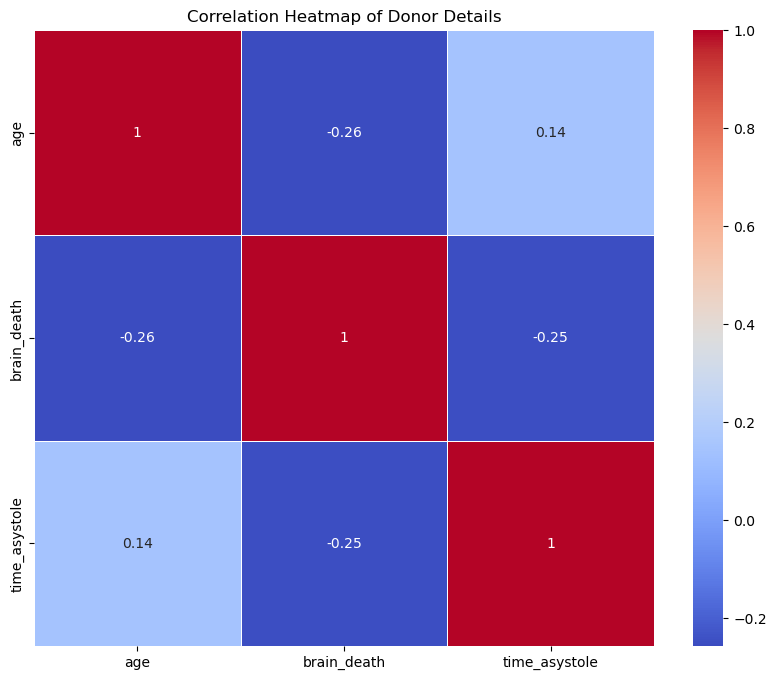

In [153]:
df1 =DonorDetails_df

selected_columns = ['age', 'brain_death', 'time_asystole']
df_selected = df1[selected_columns]

corr_matrix = df_selected.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths= 0.5 )

plt.title('Correlation Heatmap of Donor Details')
plt.show()

### 10: Create a bar chart showing the number of donors by procured year. Add hatching to the bars using the set_hatch() method, and exclude any outlier years.

### 11: Plot a Donut chart to show donor distribution by Gender. DONE

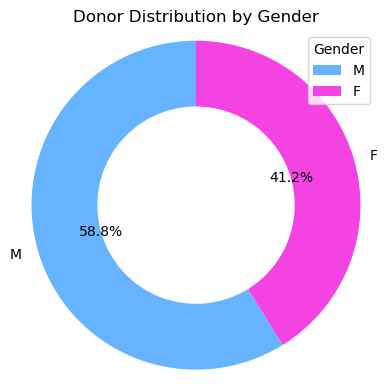

In [154]:
df1 =DonorDetails_df

# Calculate the distribution of gender
gender_counts = df1['gender'].value_counts()

# Donut Chart creation
labels = gender_counts.index
sizes = gender_counts.values
colors = ['#66b3ff','#f542e3'] 


# Create a pie chart with a hole in the middle to make it a donut chart
fig, ax = plt.subplots(figsize=(4, 4))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, wedgeprops=dict(width=0.4))

# Equal aspect ratio ensures that pie is drawn as a circle.
ax.axis('equal')
    
# Title    
plt.title('Donor Distribution by Gender')
    
# Adding a legend
plt.legend(labels, title="Gender", loc="upper right")

# Show the plot
plt.tight_layout()
plt.show()

### 12: Using loc, retrieve the race and time of aysytole of donors between indices 1001 and 2001. DONE

In [155]:
df1 =DonorDetails_df
#df1.keys()

sub_df = df1.loc[1001:2001, ['race', 'time_asystole']]

print(sub_df)

          race       time_asystole
1001     White 2034-03-28 16:47:00
1002  Hispanic                 NaT
1003     White 2034-01-19 12:00:00
1004  Hispanic 2032-01-19 18:49:00
1005  Hispanic 2036-02-05 18:31:00
...        ...                 ...
1997  Hispanic 2037-05-19 23:10:00
1998  Hispanic                 NaT
1999     White 2034-11-20 21:21:00
2000  Hispanic 2034-02-04 15:00:00
2001     White 2035-06-15 05:58:00

[1001 rows x 2 columns]


### 13: np.arange(1,31).reshape(6,5)<br>    1. Find array slicing to get the elements 1,2,8,30. <br>    2. When the value is less than 9, print as 0,else print 99 DONE

In [157]:
array = np.arange(1, 31).reshape(6, 5)
print("Array:")
print( array)

# array slicing to get the elements 1,2,8,30.
#used \n for adding blank line 
elements = [array[0, 0], array[0, 1], array[1, 2], array[5, 4]] 
print("\n1: Array slicing elements:")
print(elements)

# When the value is less than 9, print as 0,else print 99
result_array = np.where(array < 9, 0, 99)
print(f"\n2: Array of 0 and 99")

print(result_array)


Array:
[[ 1  2  3  4  5]
 [ 6  7  8  9 10]
 [11 12 13 14 15]
 [16 17 18 19 20]
 [21 22 23 24 25]
 [26 27 28 29 30]]

1: Array slicing elements:
[1, 2, 8, 30]

2: Array of 0 and 99
[[ 0  0  0  0  0]
 [ 0  0  0 99 99]
 [99 99 99 99 99]
 [99 99 99 99 99]
 [99 99 99 99 99]
 [99 99 99 99 99]]


### 14: Create subplots for the following data <br>x = np.arange(0, 10, 0.1) <br>y = np.sin(np.pi * x) + x <br>using an object-oriented approach, and arrange the subplots in a 2x2 grid layout<be>. DONE


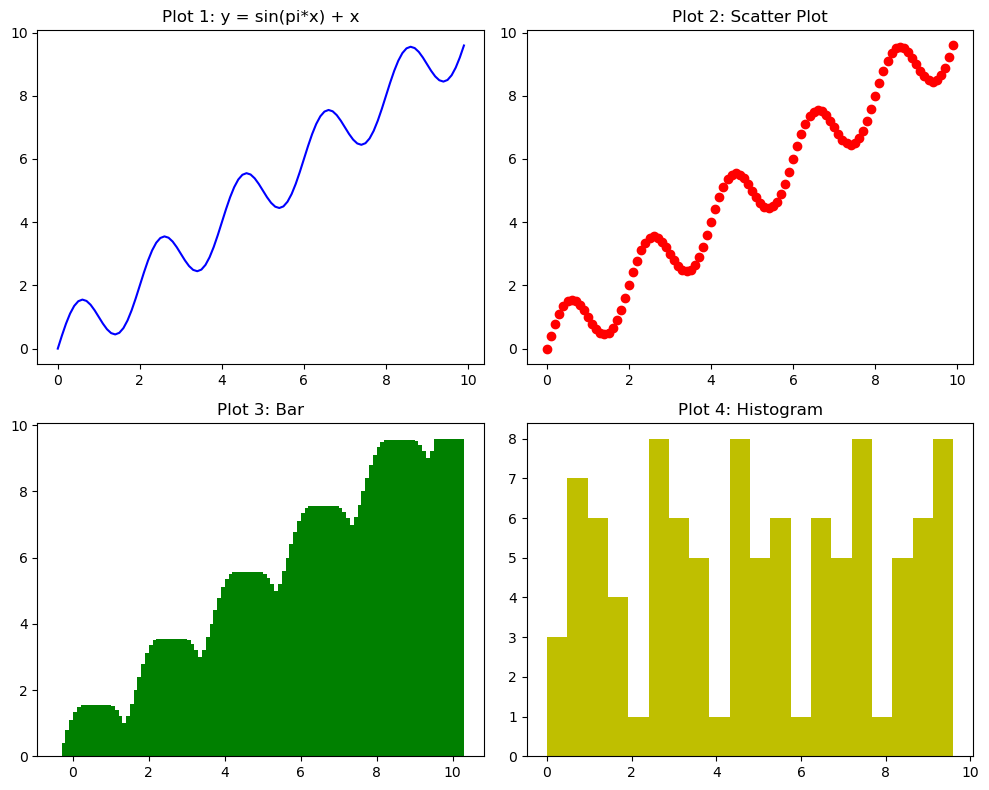

In [158]:

# Define the data
x = np.arange(0, 10, 0.1)
y = np.sin(np.pi * x) + x

# Create a figure and a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Plotting on each of the subplots
axes[0, 0].plot(x, y, 'b-')
axes[0, 0].set_title("Plot 1: y = sin(pi*x) + x")

axes[0, 1].scatter(x, y, color ='r')  # Another plot example
axes[0, 1].set_title("Plot 2: Scatter Plot")

axes[1, 0].bar(x, y, color ='g') 
axes[1, 0].set_title("Plot 3: Bar")

axes[1, 1].hist(y, bins = 20, color ='y')  
axes[1, 1].set_title("Plot 4: Histogram")

# Adjust the layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()


### 15: Create a box plot on any values in the dataset. Ensure that it is analytically correct. DONE

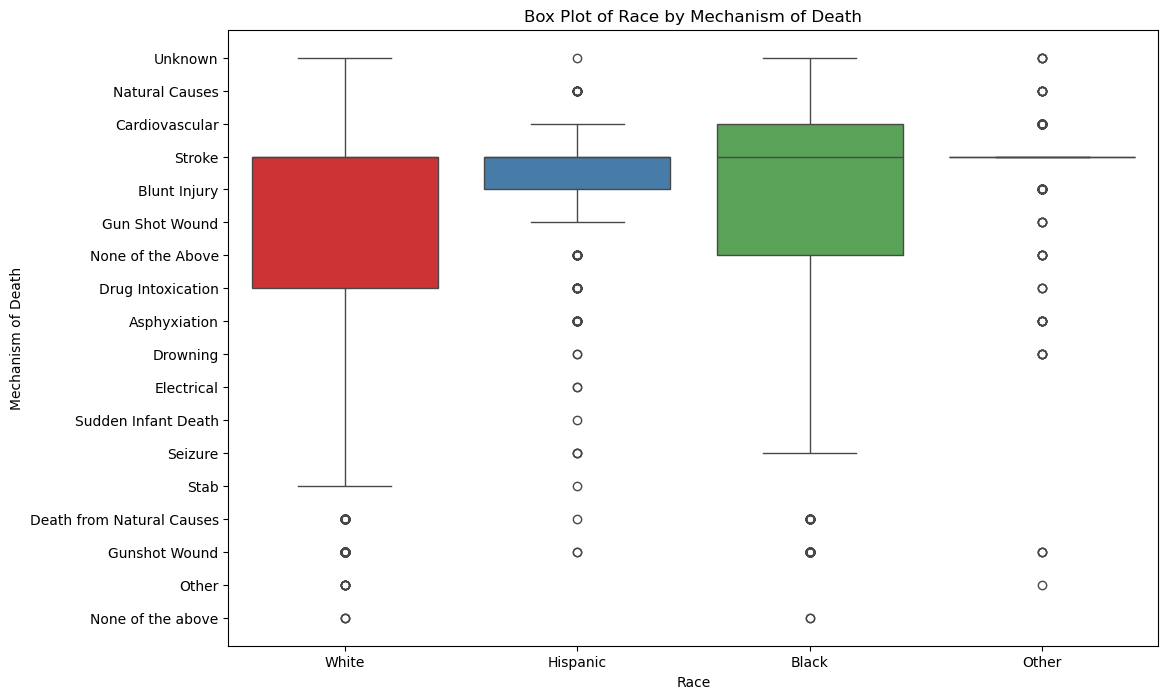

In [160]:
df1= DonorDetails_df
df1 = df1.dropna()

# creating box plot
plt.figure(figsize=(12,8))
sns.boxplot(x= 'race', y= 'mechanism_of_death', data= df1, palette='Set1')

#customizing the plot
plt.title('Box Plot of Race by Mechanism of Death')
plt.xlabel('Race')
plt.ylabel('Mechanism of Death')

plt.show()

### 16: How many donors were registered in each Organ Procurement Organization? DONE


In [161]:
df1= DonorDetails_df
df4= OPO_HospDetails_df 

# merged tables on Patient ID column
merged_df = pd.merge(df1, df4, on='PatientID')
# merged_df.info() # 133101

# grouping by OPO and counting unique Patient Id
donor_counts_by_opo = merged_df.groupby('OPO')['PatientID'].nunique()

# Index reset
donor_counts_by_opo= donor_counts_by_opo.reset_index()

#Renaming the columns
donor_counts_by_opo.columns = ['OPO', 'Donor Counts']

# show results
print(donor_counts_by_opo)

    OPO  Donor Counts
0  OPO1         32148
1  OPO2         16145
2  OPO3         12514
3  OPO4         33641
4  OPO5         15738
5  OPO6         22915


### 17: Calculate the average time between referral and procurement for each mechanism of death. DONE

In [162]:
df1= DonorDetails_df
df2 =ReferralDetails_df

# Merged data from DonorDetails and ReferralDetails tables
merged_df = pd.merge(df1, df2, on='PatientID')

# drop all null value records 
merged_df = merged_df.dropna(subset=['time_referred', 'time_procured','mechanism_of_death' ])

# Time difference between Time Reffered and Time Procured (in hours)
merged_df['time_difference_hours'] = (merged_df['time_procured'] - merged_df['time_referred']).dt.total_seconds() / 3600

# Converting Time Difference from hours to days
merged_df['time_difference_days'] = merged_df['time_difference_hours'] / 24


# Grouping by Mechnaism of Death and average of Time Diffrence
average_time_diff_days = merged_df.groupby('mechanism_of_death')['time_difference_days'].mean().reset_index()

# column name resetting
average_time_diff_days.columns = ['Mechanism of Death', 'Average Time Difference (Days)']


print("Average time between referral and procurement for each mechanism of death:")
print(average_time_diff_days)



Average time between referral and procurement for each mechanism of death:
           Mechanism of Death  Average Time Difference (Days)
0                Asphyxiation                        4.622321
1                Blunt Injury                        4.461121
2              Cardiovascular                        4.185374
3   Death from Natural Causes                        2.647945
4                    Drowning                        4.833601
5           Drug Intoxication                        4.346705
6                  Electrical                        4.646315
7              Gun Shot Wound                        3.970034
8               Gunshot Wound                        3.012094
9              Natural Causes                        4.434546
10          None of the Above                        4.214124
11          None of the above                        2.275694
12                      Other                        2.372049
13                    Seizure                        4.20

### 18: What % of all referrals are procured? DONE



In [163]:
ReferralDetails_df = dfs['ReferralDetails_df']
df2 =ReferralDetails_df
df2.head()

total_referrals = ReferralDetails_df['time_referred'].notnull().sum()
print(f"Total Referrals: ", total_referrals)

procured_count = ReferralDetails_df['time_procured'].notnull().sum()
print( f"Total Procured: " , procured_count)

percent_procured = (procured_count / total_referrals)

print(f"Percentage of total referrals that have been procured: {percent_procured:.2f}%")


Total Referrals:  133101
Total Procured:  9543
Percentage of total referrals that have been procured: 0.07%


### 19: Write a function to calculate the year of birth for each patient using year of referral as a base. DONE

In [164]:
df1= DonorDetails_df
df2 =ReferralDetails_df

# Merged data from DonorDetails and ReferralDetails tables
merged_df = pd.merge(df1, df2, on='PatientID')

# drop all null value records 
merged_df = merged_df.dropna(subset=['age', 'Referral_Year'])

# calculation of year of birth and convert into the int
merged_df['year_of_birth'] = (merged_df['Referral_Year'] - merged_df['age']).astype(int)

#display table containing patient id, age , referral year and year of birth keys
result_df = merged_df[['PatientID', 'age', 'Referral_Year', 'year_of_birth']]

result_df.head()



,PatientID,age,Referral_Year,year_of_birth
0,OPO1_P155959,54.0,2021,1967
1,OPO1_P297347,78.0,2017,1939
2,OPO1_P399316,57.0,2018,1961
3,OPO1_P246407,78.0,2019,1941
4,OPO1_P187209,70.0,2018,1948


### 20: How many patients have died of sepsis following drowning incidents? DONE


In [165]:
DonorDetails_df = dfs['DonorDetails_df']
df1= DonorDetails_df
#df1.keys()

filtered_df = df1[(df1['causeofdeath'] == 'Sepsis') & (df1['mechanism_of_death'] == "Drowning")]
pt_count = filtered_df['PatientID'].count()
print(f" Count of patient/s: ", pt_count)


 Count of patient/s:  1
